In [1]:
from pathlib import Path
import pandas as pd
import numpy as np
path = Path("data")

In [2]:
from sklearn.model_selection import train_test_split
train_df = pd.read_csv(path / "train.csv", index_col="Id")
test_df = pd.read_csv(path / "test.csv", index_col="Id")

In [3]:
GYB_max = train_df["GarageYrBlt"].max()
YS_max  = train_df["YrSold"].max()

train_df["GarageYrBlt"] = GYB_max - train_df["GarageYrBlt"]
test_df["GarageYrBlt"]  = GYB_max - test_df["GarageYrBlt"]

train_df["YrSold"] = YS_max - train_df["YrSold"]
test_df["YrSold"]  = YS_max - test_df["YrSold"]


X = train_df.drop(columns=["SalePrice", "GarageFinish", "Street",
                           "Alley", "Utilities", "Condition2", "PoolQC",
                           "RoofMatl", "Heating", "LowQualFinSF", "MiscFeature",
                           ])

test_df = test_df.drop(columns=["GarageFinish", "Street",
                           "Alley", "Utilities", "Condition2", "PoolQC",
                           "RoofMatl", "Heating", "LowQualFinSF", "MiscFeature",
                           ])

y = train_df["SalePrice"]

X_train, X_test, y_train, y_test = train_test_split(X,y, test_size=0.15)

del X, y

In [4]:
from sklearn.preprocessing import StandardScaler, OrdinalEncoder, MinMaxScaler
from category_encoders import CountEncoder, TargetEncoder

def apply_custom_mappings(train_df, test_df, test):
    mappings = {
        "PavedDrive": lambda x: 0 if x == "Y" else 1,
        "EnclosedPorch": lambda x: 0 if x == 0 else 1,
        "3SsnPorch": lambda x: 0 if x == 0 else 1,
        "ScreenPorch": lambda x: 0 if x == 0 else 1,
        "PoolArea": lambda x: 0 if x == 0 else 1,
        "MiscVal": lambda x: 0 if x == 0 else 1,
        "SaleType": lambda x: 0 if x == "WD" else 1,
        "LotShape": lambda x: 0 if x == "Reg" else (1 if x == "IR1" else 2),
        "LandContour": lambda x: 0 if x == "Lvl" else 1,
        "LandSlope": lambda x: 0 if x == "Gtl" else 1,
        "Condition1": lambda x: 0 if x == "Norm" else 1,
        "HouseStyle": lambda x: 0 if x == "1Story" else (1 if x == "2Story" else 2),
        "MSZoning": lambda x: 0 if x == "RL" else (1 if x == "RM" else 2),
        "Fence": lambda x: 0 if pd.isna(x) else 1,
        "BsmtExposure": lambda x: 2 if pd.isna(x) else (0 if x == "No" else 1),
        "BsmtFinType2": lambda x: 0 if x == "Unf" else 1,
        "BsmtFinSF2": lambda x: 0 if x == 0 else 1,
        "CentralAir": lambda x: 1 if x == "Y" else 0,
        "Electrical": lambda x: 0 if x == "SBrkr" else 1,
        "Functional": lambda x: 0 if x == "Typ" else 1,
        "RoofStyle": lambda x: 0 if x == "Gable" else (1 if x == "Hip" else 2),
        "MasVnrType": lambda x: 0 if pd.isna(x) else (1 if x == "BrkFace" else 2),
    }
    
    for col, func in mappings.items():
        train_df[col] = train_df[col].apply(func)
        test_df[col] = test_df[col].apply(func)
        test[col] = test[col].apply(func)
    return train_df, test_df, test

qual_map = {'Ex':5, 'Gd':4, 'TA':3, 'Fa':2, 'Po':1, np.nan:0}
ord_cols = ["KitchenQual", "ExterCond", "ExterQual", 
            "BsmtCond", "BsmtQual", "GarageQual", "GarageCond",
            "HeatingQC", "FireplaceQu"]
for c in ord_cols:
    for df_ in (X_train, X_test, test_df):
        df_[c] = df_[c].map(qual_map)


X_train, X_test, test_df = apply_custom_mappings(X_train, X_test, test_df)

countercols = ["BsmtFinType1", "Foundation"]
def encoder(tr, va, te):
    name = tr.name
    ec = CountEncoder(cols=[name])
    tr_s = ec.fit_transform(tr.to_frame())[name].astype(float)
    m = float(tr_s.max()) if tr_s.max() != 0 else 1.0
    va_s = ec.transform(va.to_frame())[name].astype(float).fillna(0.0)
    te_s = ec.transform(te.to_frame())[name].astype(float).fillna(0.0)
    return tr_s/m, va_s/m, te_s/m

oscols = ["GarageType", "SaleCondition", "LotConfig", "BldgType"]
def oscale(tr, va, te):
    tr_n, va_n, te_n = tr.to_numpy().reshape(-1,1), va.to_numpy().reshape(-1,1), te.to_numpy().reshape(-1,1)
    oscaler = OrdinalEncoder(handle_unknown="use_encoded_value", unknown_value=-1)
    tr_n = oscaler.fit_transform(tr_n).ravel()
    va_n = oscaler.transform(va_n).ravel()
    te_n = oscaler.transform(te_n).ravel()
    return pd.Series(tr_n, index=tr.index), pd.Series(va_n, index=va.index), pd.Series(te_n, index=te.index)

mcols = ["MoSold", "YrSold", "OverallQual", "OverallCond", "KitchenQual"]
def mmax(tr, va, te):
    if tr.isna().any().any() or va.isna().any().any() or te.isna().any().any():
        raise ValueError(f"NaN value found in dataset tr:{tr.isna().any().any()} va{va.isna().any().any()} te: {te.isna().any().any()}")
    tr /= tr.max()
    va /= tr.max()
    te /= tr.max()

    return tr, va, te

scols = ["WoodDeckSF", "OpenPorchSF", "LotArea", 
         "MSSubClass", "BsmtUnfSF", "TotalBsmtSF",
         "1stFlrSF", "GrLivArea", "GarageArea",
         "MasVnrArea", "LotFrontage"]
def sscaler(tr, va, te):
    ss = StandardScaler()
    tr = ss.fit_transform(tr)
    va = ss.transform(va)
    te = ss.transform(te)
    return tr.ravel(), va.ravel(), te.ravel()

tcols = ['Neighborhood','Exterior1st','Exterior2nd']
def tencoding(tr, va, te, y_tr):
    tec = TargetEncoder()
    tr = tec.fit_transform(tr, y_tr)
    va = tec.transform(va)
    te = tec.transform(te)
    return tr, va, te

X_train['LotArea'] = np.log1p(X_train['LotArea'])
X_test['LotArea'] = np.log1p(X_test['LotArea'])
test_df['LotArea'] = np.log1p(test_df['LotArea'])

X_train['2ndFlrSF'] = np.log1p(X_train['2ndFlrSF'])
X_test['2ndFlrSF'] = np.log1p(X_test['2ndFlrSF'])
test_df['2ndFlrSF'] = np.log1p(test_df['2ndFlrSF'])

X_train['BsmtFinType1'] = X_train['BsmtFinType1'].fillna('NoBsmt')
X_test['BsmtFinType1'] = X_test['BsmtFinType1'].fillna('NoBsmt')
test_df['BsmtFinType1'] = test_df['BsmtFinType1'].fillna('NoBsmt')

X_train['GarageYrBlt'] = X_train['GarageYrBlt'].fillna(-1)
X_test['GarageYrBlt'] = X_test['GarageYrBlt'].fillna(-1)
test_df['GarageYrBlt'] = test_df['GarageYrBlt'].fillna(-1)

X_train['GarageYrBlt'] = (X_train['GarageYrBlt'] + 1e-7) / X_train['GarageYrBlt'].max()
X_test['GarageYrBlt']  = (X_test['GarageYrBlt']  + 1e-7) / X_train['GarageYrBlt'].max()
test_df['GarageYrBlt']  = (test_df['GarageYrBlt']  + 1e-7) / X_train['GarageYrBlt'].max()

X_train['GarageType'] = X_train['GarageType'].fillna("Nogrg")
X_test['GarageType'] = X_test['GarageType'].fillna("Nogrg")
test_df['GarageType'] = test_df['GarageType'].fillna("Nogrg")

lot_median = X_train.groupby("Neighborhood")['LotFrontage'].median()

X_train['LotFrontage'] = X_train.apply(
    lambda row: lot_median[row["Neighborhood"]]                                  
    if pd.isna(row["LotFrontage"]) else row["LotFrontage"], 
    axis=1)

X_test["LotFrontage"] = X_test.apply(
    lambda row: lot_median[row["Neighborhood"]] 
    if pd.isna(row["LotFrontage"]) else row["LotFrontage"],
    axis=1
)

test_df["LotFrontage"] = test_df.apply(
    lambda row: lot_median[row["Neighborhood"]] 
    if pd.isna(row["LotFrontage"]) else row["LotFrontage"],
    axis=1
)

for df_ in (X_train, X_test, test_df):
    df_['TotalSF']   = df_['TotalBsmtSF'] + df_['1stFlrSF'] + df_['2ndFlrSF']
    
    df_['Age']       = df_['YrSold'] - df_['YearBuilt']
    
    df_['RemodAge']  = df_['YrSold'] - df_['YearRemodAdd']
    
    df_['TotalBath'] = df_['FullBath'] + 0.5*df_['HalfBath'] + df_['BsmtFullBath'] + 0.5*df_['BsmtHalfBath']
    
    df_['HasBsmt']   = (df_['TotalBsmtSF'] > 0).astype(int)
    
    df_['OverallGrade'] = df_['OverallQual'] * df_['OverallCond']
    
    df_['QualAge']   = df_['OverallQual'] * df_['Age']


for col in oscols:
    X_train[col], X_test[col], test_df[col] = oscale(X_train[col], X_test[col], test_df[col])
for col in countercols:
    X_train[col], X_test[col], test_df[col] = encoder(X_train[col], X_test[col], test_df[col])
for col in scols:
    X_train[col], X_test[col], test_df[col] = sscaler(X_train[col].to_numpy().reshape(-1, 1), 
                                        X_test[col].to_numpy().reshape(-1, 1),
                                        test_df[col].to_numpy().reshape(-1, 1))
for col in mcols:
    X_train[col], X_test[col], test_df[col] = mmax(X_train[col], X_test[col], test_df[col])
for col in tcols:
    X_train[col], X_test[col], test_df[col] = tencoding(X_train[col], X_test[col], test_df[col], y_train)

In [5]:
test_df = test_df[X_train.columns]

In [6]:
X_train.isna().any().any()

np.True_

In [7]:
test_df.columns[test_df.isna().any()]

Index(['MasVnrArea', 'BsmtFinSF1', 'BsmtUnfSF', 'TotalBsmtSF', 'BsmtFullBath',
       'BsmtHalfBath', 'GarageCars', 'GarageArea', 'TotalSF', 'TotalBath'],
      dtype='object')

In [8]:
bad_rows = test_df.index[test_df.isna().any(axis=1)]
bad_cols = test_df.columns[test_df.isna().any()]
fill_vals = X_train.median(numeric_only=True)
test_df[bad_cols] = test_df[bad_cols].fillna(fill_vals[bad_cols])

In [9]:
from sklearn.preprocessing import StandardScaler

def zscore_if_median_gt1(X_train, X_valid, X_test):
    scaler = StandardScaler()
    numeric_cols = X_train.select_dtypes(include=[np.number]).columns
    
    cols_to_scale = [col for col in numeric_cols if X_train[col].median() > 1]
    
    X_train_scaled = X_train.copy()
    X_valid_scaled = X_valid.copy()
    X_test_scaled = X_test.copy()
    
    X_train_scaled[cols_to_scale] = scaler.fit_transform(X_train[cols_to_scale])
    X_valid_scaled[cols_to_scale] = scaler.transform(X_valid[cols_to_scale])
    X_test_scaled[cols_to_scale]  = scaler.transform(X_test[cols_to_scale])
    
    return X_train_scaled, X_valid_scaled, X_test_scaled, cols_to_scale

# Kullanım
X_train, X_test, test_df, scaled_cols = zscore_if_median_gt1(X_train, X_test, test_df)
print("Z-score uygulanan kolonlar:", scaled_cols)


Z-score uygulanan kolonlar: ['LotConfig', 'Neighborhood', 'YearBuilt', 'YearRemodAdd', 'Exterior1st', 'Exterior2nd', 'ExterQual', 'ExterCond', 'BsmtQual', 'BsmtCond', 'BsmtFinSF1', 'HeatingQC', 'FullBath', 'BedroomAbvGr', 'TotRmsAbvGrd', 'FireplaceQu', 'GarageCars', 'GarageQual', 'GarageCond', 'SaleCondition', 'TotalSF', 'TotalBath', 'OverallGrade']


In [10]:
import xgboost as xgb
from sklearn.metrics import root_mean_squared_error, mean_squared_error

params = dict(
    booster="gbtree",
    learning_rate=5e-4,         
    n_estimators=30000,         
    max_depth=8,                
    min_child_weight=1,         
    gamma=0.1,                  # split için min. kazanç
    subsample=0.7,              # row sampling
    colsample_bytree=0.7,       # feature sampling
    reg_alpha=2.0,              # L1
    reg_lambda=5.0,             # L2
    max_bin=256,                
    grow_policy="lossguide",    
    tree_method="hist",         
    device="cuda",              
    random_state=42,
    eval_metric="rmse"
)

y_train = np.log1p(y_train)
y_test = np.log1p(y_test)

dtrain = xgb.DMatrix(X_train, label=y_train)
dvalid = xgb.DMatrix(X_test, label=y_test)
dtest = xgb.DMatrix(test_df)

model = xgb.train(
    params,
    dtrain,
    num_boost_round=30000,
    evals=[(dtrain, "train"), (dvalid, "valid")],
    early_stopping_rounds=500,
    verbose_eval=200
)

pred_log = model.predict(dvalid, iteration_range=(0, model.best_iteration+1))
rmsle = root_mean_squared_error(y_test, pred_log)
print("RMSLE:", rmsle)

[0]	train-rmse:0.40104	valid-rmse:0.38896


/home/tunahan/anaconda3/envs/ml_env/lib/python3.11/site-packages/xgboost/callback.py:386: UserWarning: [13:35:15] WARNING: /workspace/src/learner.cc:738: 
Parameters: { "n_estimators" } are not used.

  self.starting_round = model.num_boosted_rounds()


[200]	train-rmse:0.37488	valid-rmse:0.36598
[400]	train-rmse:0.35133	valid-rmse:0.34549
[600]	train-rmse:0.33003	valid-rmse:0.32705
[800]	train-rmse:0.31069	valid-rmse:0.31044
[1000]	train-rmse:0.29320	valid-rmse:0.29550
[1200]	train-rmse:0.27735	valid-rmse:0.28194
[1400]	train-rmse:0.26302	valid-rmse:0.26971
[1600]	train-rmse:0.25002	valid-rmse:0.25868
[1800]	train-rmse:0.23824	valid-rmse:0.24888
[2000]	train-rmse:0.22750	valid-rmse:0.23976
[2200]	train-rmse:0.21775	valid-rmse:0.23137
[2400]	train-rmse:0.20883	valid-rmse:0.22389
[2600]	train-rmse:0.20074	valid-rmse:0.21716
[2800]	train-rmse:0.19341	valid-rmse:0.21108
[3000]	train-rmse:0.18668	valid-rmse:0.20539
[3200]	train-rmse:0.18054	valid-rmse:0.20045
[3400]	train-rmse:0.17493	valid-rmse:0.19586
[3600]	train-rmse:0.16983	valid-rmse:0.19162
[3800]	train-rmse:0.16515	valid-rmse:0.18771
[4000]	train-rmse:0.16088	valid-rmse:0.18427
[4200]	train-rmse:0.15694	valid-rmse:0.18108
[4400]	train-rmse:0.15335	valid-rmse:0.17814
[4600]	train-r

In [11]:
preds = np.expm1(model.predict(dtest, iteration_range=(0, model.best_iteration+1)))
sub = pd.DataFrame({"Id": test_df.index, "SalePrice": preds})
sub.to_csv("submission.csv", index=False)
print(pd.read_csv("submission.csv").head()) 

     Id  SalePrice
0  1461  139645.62
1  1462  166563.53
2  1463  192372.19
3  1464  195185.77
4  1465  198074.48


In [12]:
import shap
explainer = shap.TreeExplainer(model)
shap_values = explainer.shap_values(X_test)

/home/tunahan/anaconda3/envs/ml_env/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


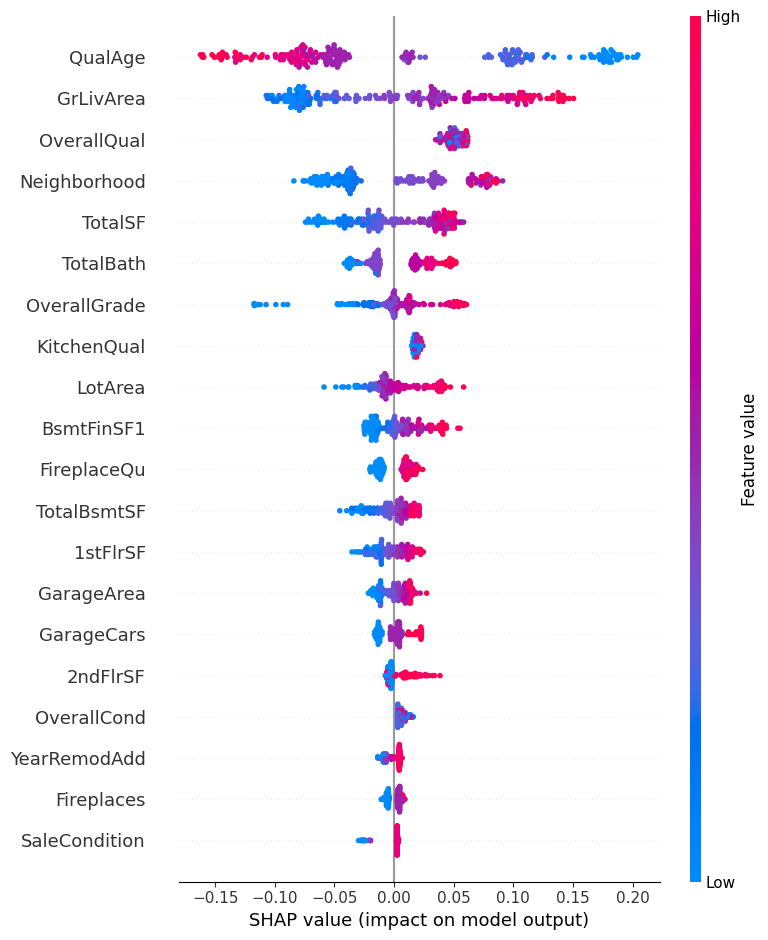

In [13]:
shap.summary_plot(shap_values, X_test)

In [14]:
shap.initjs()
shap.force_plot(
    explainer.expected_value,
    shap_values[0, :],
    X_test.iloc[0,:]
)

GarageType, ExterQual, 2ndFlrSF, MSZoning, FireplaceQu, KitchenQual, BsmtQual

In [15]:
from sklearn.inspection import permutation_importance

xgb_sklearn = xgb.XGBRegressor(
    booster="gbtree",
    learning_rate=0.0005,  
    n_estimators=model.best_iteration+1,  
    max_depth=8,
    min_child_weight=1,
    gamma=0.1,
    subsample=0.7,
    colsample_bytree=0.7,
    reg_alpha=2.0,
    reg_lambda=5.0,
    max_bin=256,
    grow_policy="lossguide",
    tree_method="hist",
    random_state=42
)

xgb_sklearn.fit(X_train, y_train)  

perm_result = permutation_importance(
    xgb_sklearn,
    X_test,
    y_test,
    n_repeats=10,
    random_state=42,
    scoring="neg_root_mean_squared_error"
)

perm_df = pd.DataFrame({
    "feature": X_test.columns,
    "importance_mean": perm_result.importances_mean,
    "importance_std": perm_result.importances_std
}).sort_values(by="importance_mean", ascending=False)

print(perm_df.head(15))

         feature  importance_mean  importance_std
75       QualAge         0.066931        0.006713
38     GrLivArea         0.057404        0.006648
8   Neighborhood         0.026783        0.003131
69       TotalSF         0.018905        0.004683
74  OverallGrade         0.017346        0.002549
72     TotalBath         0.011143        0.002162
3        LotArea         0.007296        0.002943
28    BsmtFinSF1         0.006450        0.001383
36      1stFlrSF         0.005537        0.002375
32   TotalBsmtSF         0.005043        0.001849
53    GarageArea         0.004672        0.000654
52    GarageCars         0.003984        0.000572
49   FireplaceQu         0.003247        0.000932
15  YearRemodAdd         0.002613        0.000484
14     YearBuilt         0.002552        0.000773


In [16]:
print(perm_df.tail(25))

          feature  importance_mean  importance_std
19     MasVnrType     1.798428e-05    1.011333e-05
11     HouseStyle     1.109414e-05    7.266594e-06
60      3SsnPorch     9.606756e-06    1.065091e-05
2     LotFrontage     8.908672e-06    4.109753e-04
18    Exterior2nd     3.853273e-06    6.418817e-06
5     LandContour     2.276707e-06    1.052501e-06
30     BsmtFinSF2     2.039256e-06    7.204098e-06
6       LotConfig     1.976156e-06    7.374569e-06
7       LandSlope     4.321952e-07    1.277254e-06
59  EnclosedPorch     3.869130e-07    1.100432e-06
45    KitchenQual     0.000000e+00    0.000000e+00
73        HasBsmt     0.000000e+00    0.000000e+00
65         MoSold     0.000000e+00    0.000000e+00
12    OverallQual     0.000000e+00    0.000000e+00
13    OverallCond     0.000000e+00    0.000000e+00
63          Fence    -2.862571e-07    3.385303e-07
17    Exterior1st    -1.478559e-06    2.974290e-05
29   BsmtFinType2    -1.835472e-06    1.427725e-06
67       SaleType    -2.037264e

In [22]:
low_imp_feats = [
    "PavedDrive", "RoofStyle", "BsmtFinType2", "EnclosedPorch", "MiscVal",
    "HasBsmt", "MoSold", "OverallQual", "OverallCond", "KitchenQual",
    "LandSlope", "PoolArea", "Fence", "SaleType", "BsmtFinSF2", "LandContour",
    "ExterCond", "Exterior1st", "3SsnPorch", "YrSold", "Electrical",
    "BsmtFinType1", "HouseStyle", "BedroomAbvGr", "OpenPorchSF",
    "LotFrontage", "WoodDeckSF", "HalfBath", "ScreenPorch", "BsmtUnfSF",
    "MasVnrArea", "MasVnrType", "LotConfig", "LotShape", "Exterior2nd",
    "BldgType", "BsmtFullBath", "FullBath", "BsmtExposure", "BsmtCond"

]

X_train_red = X_train.drop(columns=low_imp_feats, errors="ignore")
X_test_red  = X_test.drop(columns=low_imp_feats, errors="ignore")
test_df_red = test_df.drop(columns=low_imp_feats, errors="ignore")

In [23]:
xgb_sklearn = xgb.XGBRegressor(
    **params,
    early_stopping_rounds=500,
)
xgb_sklearn.fit(
    X_train_red, y_train,
    eval_set=[(X_train_red, y_train), (X_test_red, y_test)],
    verbose=200
)

[0]	validation_0-rmse:0.40105	validation_1-rmse:0.38893
[200]	validation_0-rmse:0.37495	validation_1-rmse:0.36411
[400]	validation_0-rmse:0.35146	validation_1-rmse:0.34183
[600]	validation_0-rmse:0.33015	validation_1-rmse:0.32172
[800]	validation_0-rmse:0.31087	validation_1-rmse:0.30355
[1000]	validation_0-rmse:0.29338	validation_1-rmse:0.28709
[1200]	validation_0-rmse:0.27757	validation_1-rmse:0.27220
[1400]	validation_0-rmse:0.26335	validation_1-rmse:0.25898
[1600]	validation_0-rmse:0.25042	validation_1-rmse:0.24695
[1800]	validation_0-rmse:0.23871	validation_1-rmse:0.23608
[2000]	validation_0-rmse:0.22807	validation_1-rmse:0.22630
[2200]	validation_0-rmse:0.21840	validation_1-rmse:0.21747
[2400]	validation_0-rmse:0.20960	validation_1-rmse:0.20944
[2600]	validation_0-rmse:0.20161	validation_1-rmse:0.20221
[2800]	validation_0-rmse:0.19435	validation_1-rmse:0.19562
[3000]	validation_0-rmse:0.18767	validation_1-rmse:0.18961
[3200]	validation_0-rmse:0.18165	validation_1-rmse:0.18421
[340

,objective,'reg:squarederror'
,base_score,None
,booster,'gbtree'
,callbacks,None
,colsample_bylevel,None
,colsample_bynode,None
,colsample_bytree,0.7
,device,'cuda'
,early_stopping_rounds,500
,enable_categorical,False
,eval_metric,'rmse'


In [24]:
pred_log = xgb_sklearn.predict(X_test_red, iteration_range=(0, model.best_iteration+1))
rmsle = root_mean_squared_error(y_test, pred_log)
print("RMSLE:", rmsle)

RMSLE: 0.12143564282444803


In [25]:
perm_result = permutation_importance(
    xgb_sklearn,
    X_test_red,
    y_test,
    n_repeats=10,
    random_state=42,
    scoring="neg_root_mean_squared_error",
    n_jobs=12
)

perm_df = pd.DataFrame({
    "feature": X_test_red.columns,
    "importance_mean": perm_result.importances_mean,
    "importance_std": perm_result.importances_std
}).sort_values(by="importance_mean", ascending=False)

print(perm_df.tail(15))

/home/tunahan/anaconda3/envs/ml_env/lib/python3.11/site-packages/xgboost/core.py:729: UserWarning: [13:43:14] WARNING: /workspace/src/common/error_msg.cc:58: Falling back to prediction using DMatrix due to mismatched devices. This might lead to higher memory usage and slower performance. XGBoost is running on: cuda:0, while the input data is on: cpu.
Potential solutions:
- Use a data structure that matches the device ordinal in the booster.
- Set the device for booster before call to inplace_predict.

This warning will only be shown once.

  return func(**kwargs)
/home/tunahan/anaconda3/envs/ml_env/lib/python3.11/site-packages/xgboost/core.py:729: UserWarning: [13:43:14] WARNING: /workspace/src/common/error_msg.cc:58: Falling back to prediction using DMatrix due to mismatched devices. This might lead to higher memory usage and slower performance. XGBoost is running on: cuda:0, while the input data is on: cpu.
Potential solutions:
- Use a data structure that matches the device ordinal i

         feature  importance_mean  importance_std
5      YearBuilt         0.000636        0.000957
15      2ndFlrSF         0.000582        0.001606
1       MSZoning         0.000568        0.000157
21    Fireplaces         0.000513        0.000567
23    GarageType         0.000508        0.000296
0     MSSubClass         0.000431        0.000682
27    GarageQual         0.000320        0.000067
31           Age         0.000231        0.000444
18  KitchenAbvGr         0.000149        0.000269
4     Condition1         0.000125        0.000179
17  BsmtHalfBath         0.000124        0.000136
8     Foundation         0.000116        0.000080
20    Functional         0.000069        0.000084
24   GarageYrBlt         0.000038        0.000019
19  TotRmsAbvGrd        -0.000043        0.000227


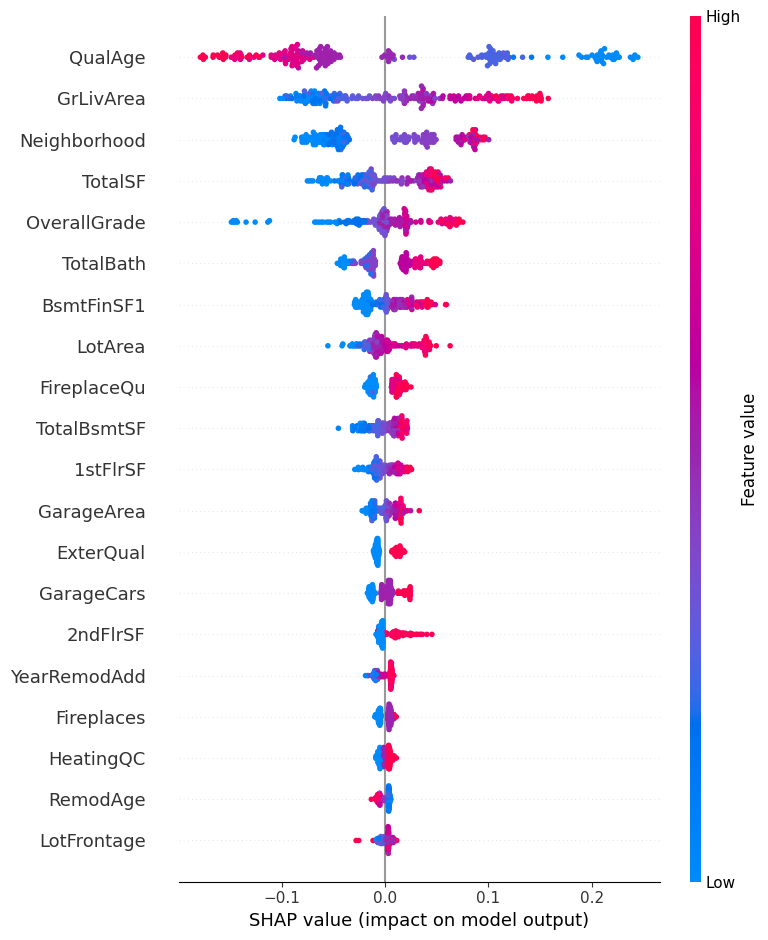

In [21]:
explainer = shap.TreeExplainer(xgb_sklearn)
shap_values = explainer.shap_values(X_test_red)
shap.summary_plot(shap_values, X_test_red)

In [26]:
X_train_red.columns

Index(['MSSubClass', 'MSZoning', 'LotArea', 'Neighborhood', 'Condition1',
       'YearBuilt', 'YearRemodAdd', 'ExterQual', 'Foundation', 'BsmtQual',
       'BsmtFinSF1', 'TotalBsmtSF', 'HeatingQC', 'CentralAir', '1stFlrSF',
       '2ndFlrSF', 'GrLivArea', 'BsmtHalfBath', 'KitchenAbvGr', 'TotRmsAbvGrd',
       'Functional', 'Fireplaces', 'FireplaceQu', 'GarageType', 'GarageYrBlt',
       'GarageCars', 'GarageArea', 'GarageQual', 'GarageCond', 'SaleCondition',
       'TotalSF', 'Age', 'RemodAge', 'TotalBath', 'OverallGrade', 'QualAge'],
      dtype='object')